## In this we show resonator induced phase for two Superconducting Qubit coupled thorugh a resonator under constant drive amplitude and reproduce the graphs given in literature. 

## Reference
> Cross & Gambetta, *Phys. Rev. A* **91**, 032325 (2015). DOI: [10.1103/PhysRevA.91.032325](https://doi.org/10.1103/PhysRevA.91.032325)

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from qutip import *
import pandas as pd
import os
import matplotlib.colors as mcolors
%matplotlib widget 

In [3]:

w1= 5 * 2 * np.pi           
w2= 4.95 * 2 * np.pi           
wr = 7 * 2 * np.pi  

chi00 = 0.01422 *2*np.pi
delr = 0.01 *2*np.pi
wd = wr+chi00+delr 

g1 = 0.12 * 2 * np.pi       
g2 = 0.12 * 2 * np.pi   

N = 15                      
tl1= 1e6                   
tl2= 1e6                    
tp1 = 1e3                   
tp2 = 1e3                   
k = 0.00005 * 2 * np.pi        
e = 0.02*2*np.pi
ei = e/(np.sqrt(2))
eq = e/(np.sqrt(2))

q_sm = basis(2,0)*basis(2,1).dag()
q_sp = basis(2,1)*basis(2,0).dag()

a = tensor(qeye(3), qeye(3), destroy(N))  
sm1 = tensor(destroy(3), qeye(3), qeye(N))      
sm2 = tensor(qeye(3), destroy(3), qeye(N))      

sz1 = tensor(basis(3,0)*basis(3,0).dag()-basis(3,1)*basis(3,1).dag()+basis(3,2)*basis(3,2).dag(),qeye(3), qeye(N))
sz2 = tensor(qeye(3),basis(3,0)*basis(3,0).dag()-basis(3,1)*basis(3,1).dag()+basis(3,2)*basis(3,2).dag(), qeye(N))

num = a.dag() * a                       
r_x = (a+a.dag())
r_Y = (a-a.dag())

s00 = tensor(basis(3,0),basis(3,0))
s01 = tensor(basis(3,0),basis(3,1))
s10 = tensor(basis(3,1),basis(3,0))
s11 = tensor(basis(3,1),basis(3,1))

p01 = s00*s01.dag()
p10 = s00*s10.dag()
p11 = s00*s11.dag()

prj0001 = tensor(p01,qeye(N))
prj0010 = tensor(p10,qeye(N))
prj0011 = tensor(p11,qeye(N))
sigmax1 = tensor(basis(3,0)*basis(3,1).dag()+basis(3,1)*basis(3,0).dag()+basis(3,2)*basis(3,2).dag(),qeye(3),qeye(N))
sigmax2 = tensor(qeye(3),basis(3,0)*basis(3,1).dag()+basis(3,1)*basis(3,0).dag()+basis(3,2)*basis(3,2).dag(),qeye(N))
xx = sigmax1*sigmax2
yy = tensor(
    basis(3,0)*basis(3,1).dag() - basis(3,1)*basis(3,0).dag()+basis(3,2)*basis(3,2).dag(),
    basis(3,0)*basis(3,1).dag() - basis(3,1)*basis(3,0).dag()+basis(3,2)*basis(3,2).dag(),
    qeye(N)
)

phase_op = xx + 1j*yy
#I = tensor(qeye(2), qeye(2), qeye(N))
c_ops = []
# Qubit 1 relaxation
#c_ops.append(np.sqrt(1/tl1) * sm1)
# Qubit 2 relaxation
#c_ops.append(np.sqrt(1/tl2) * sm2)
# Qubit 1 dephasing
#c_ops.append(np.sqrt(1/(2*tp1)) * sz1)
# Qubit 2 dephasing
#c_ops.append(np.sqrt(1/(2*tp2)) * sz2)
# Resonator decay
c_ops.append(np.sqrt(k) * a)

d1 = -0.3 * 2* np.pi
d2 = -0.3 * 2 *np.pi

In [4]:
H01 = (w1 - wd) * sm1.dag() * sm1+ (d1 / 2) * (sm1.dag() * sm1 * sm1.dag() * sm1)+ (d1 / 2) * (sm1.dag() * sm1) 
H02 = (w2 - wd) * sm2.dag() * sm2+ (d2 / 2) * (sm2.dag() * sm2 * sm2.dag() * sm2)+ (d2 / 2) * (sm2.dag() * sm2)
Hp =((wr - wd) * a.dag() * a
    + g1 * (sm1 * a.dag())
    + g1 * (sm1.dag() * a)
    + g2 * (sm2 * a.dag())
    + g2 * (sm2.dag() * a)
    + (e / 2) * a
    + (e / 2) * a.dag()
)    

In [ ]:
H = (
    (w1 - wd) * sm1.dag() * sm1
    + (d1 / 2) * (sm1.dag() * sm1 * sm1.dag() * sm1)
    + (d1 / 2) * (sm1.dag() * sm1)
    + (w2 - wd) * sm2.dag() * sm2
    + (d2 / 2) * (sm2.dag() * sm2 * sm2.dag() * sm2)
    + (d2 / 2) * (sm2.dag() * sm2)
    + (wr - wd) * a.dag() * a
    + g1 * (sm1 * a.dag())
    + g1 * (sm1.dag() * a)
    + g2 * (sm2 * a.dag())
    + g2 * (sm2.dag() * a)
    + (ei / 2) * a
    + (ei / 2) * a.dag()
    - 1j*(eq / 2) * a
    + 1j*(eq / 2) * a.dag()
    
)


H_cck = (
    - (w1 - wd) * sm1.dag() * sm1
    - (d1 / 2) * (sm1.dag() * sm1 * sm1.dag() * sm1)
    - (d1 / 2) * (sm1.dag() * sm1)
    - (w2 - wd) * sm2.dag() * sm2
    - (d2 / 2) * (sm2.dag() * sm2 * sm2.dag() * sm2)
    - (d2 / 2) * (sm2.dag() * sm2)
    - (wr - wd) * a.dag() * a
    - g1 * (sm1 * a.dag())
    - g1 * (sm1.dag() * a)
    - g2 * (sm2 * a.dag())
    - g2 * (sm2.dag() * a)
    + (ei / 2) * a
    + (ei / 2) * a.dag()
    - 1j*(eq / 2) * a
    + 1j*(eq / 2) * a.dag()
    
)

H_wd = (
    (w1 - wd) * sm1.dag() * sm1
    + (d1 / 2) * (sm1.dag() * sm1 * sm1.dag() * sm1)
    + (d1 / 2) * (sm1.dag() * sm1)
    + (w2 - wd) * sm2.dag() * sm2
    + (d2 / 2) * (sm2.dag() * sm2 * sm2.dag() * sm2)
    + (d2 / 2) * (sm2.dag() * sm2)
    + (wr - wd) * a.dag() * a
    + g1 * (sm1 * a.dag())
    + g1 * (sm1.dag() * a)
    + g2 * (sm2 * a.dag())
    + g2 * (sm2.dag() * a)
        
)

H_qubits = (
    (w1 - wd) * sm1.dag() * sm1
    + (d1 / 2) * (sm1.dag() * sm1 * sm1.dag() * sm1)
    + (d1 / 2) * (sm1.dag() * sm1)
    + (w2 - wd) * sm2.dag() * sm2
    + (d2 / 2) * (sm2.dag() * sm2 * sm2.dag() * sm2)
    + (d2 / 2) * (sm2.dag() * sm2)
    + (wr - wd) * a.dag() * a
    
)


In [6]:
tlist1 = np.linspace(0,1000,60000)
psi0 = tensor((basis(3,0)+basis(3,1)).unit(),(basis(3,0)+basis(3,1)).unit(),basis(N,0))
rho0 = psi0*psi0.dag()

In [7]:
output1 = mesolve(H,psi0,tlist1,c_ops= c_ops,e_ops=[num,r_x,r_Y,a,prj0001,prj0010,prj0011,xx,yy,phase_op],options= {'store_states': False,'progress_bar':True})

10.0%. Run time:  28.01s. Est. time left: 00:00:04:12
20.0%. Run time:  76.54s. Est. time left: 00:00:05:06
30.0%. Run time: 163.13s. Est. time left: 00:00:06:20
40.0%. Run time: 262.66s. Est. time left: 00:00:06:33
50.0%. Run time: 373.52s. Est. time left: 00:00:06:13
60.0%. Run time: 489.58s. Est. time left: 00:00:05:26
70.0%. Run time: 609.01s. Est. time left: 00:00:04:20
80.0%. Run time: 717.98s. Est. time left: 00:00:02:59
90.0%. Run time: 833.93s. Est. time left: 00:00:01:32
100.0%. Run time: 942.27s. Est. time left: 00:00:00:00
Total run time: 942.27s


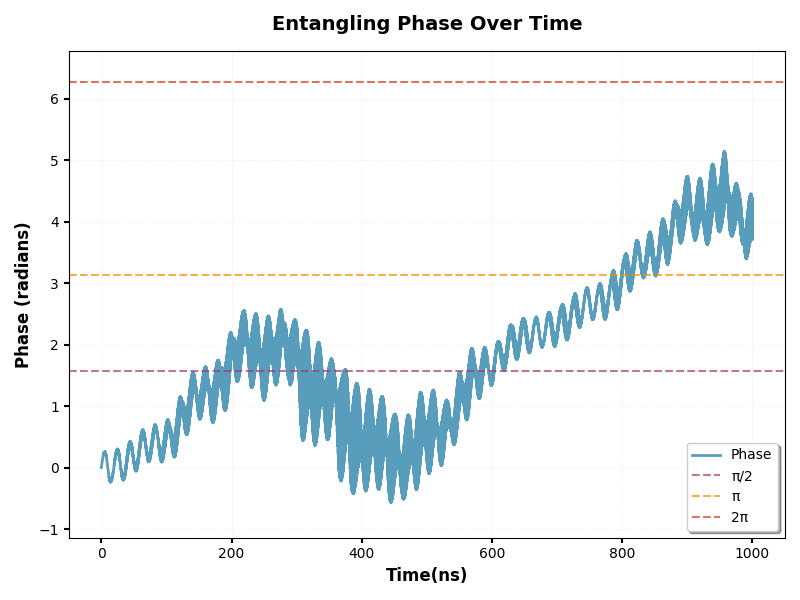

In [8]:
a1 =np.unwrap(np.angle(np.asarray(output1.expect[4])))
a2 =np.unwrap(np.angle(np.asarray(output1.expect[5])))
a3 =np.unwrap(np.angle(np.asarray(output1.expect[6])))

theta_2 = np.unwrap(np.angle(output1.expect[7]))

theta_0 = a1+a2-a3
theta3= np.angle(np.asarray(output1.expect[7])+1j*np.asarray(output1.expect[8]))
fig, ax1 = plt.subplots(1, 1, figsize=(8, 6))
ax1.plot(tlist1, theta_0, label='Phase', linewidth=2, color='#2E86AB', alpha=0.8)
ax1.axhline(y=np.pi/2, color='#A23B72', linestyle='--', linewidth=1.5, alpha=0.7, label='π/2')
ax1.axhline(y=np.pi, color='#F18F01', linestyle='--', linewidth=1.5, alpha=0.7, label='π')
ax1.axhline(y=2*np.pi, color='#C73E1D', linestyle='--', linewidth=1.5, alpha=0.7, label='2π')
ax1.legend(loc='best', frameon=True, fancybox=True, shadow=True, fontsize=10)
ax1.set_xlabel('Time(ns)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Phase (radians)', fontsize=12, fontweight='bold')
ax1.set_title('Entangling Phase Over Time', fontsize=14, fontweight='bold', pad=15)
ax1.grid(True, alpha=0.3, linestyle=':', linewidth=0.5)
ax1.set_axisbelow(True)  
y_min = min(min(theta_0), min(theta3), 0) +2
y_max = max(max(theta_0), max(theta3), 2*np.pi) + 0.5
ax1.set_ylim(y_min, y_max)
ax1.tick_params(axis='both', which='major', labelsize=10, width=1.5)
ax1.tick_params(axis='both', which='minor', labelsize=8)
ax1.spines['top'].set_visible(True)
ax1.spines['right'].set_visible(True)
plt.tight_layout()
plt.show()


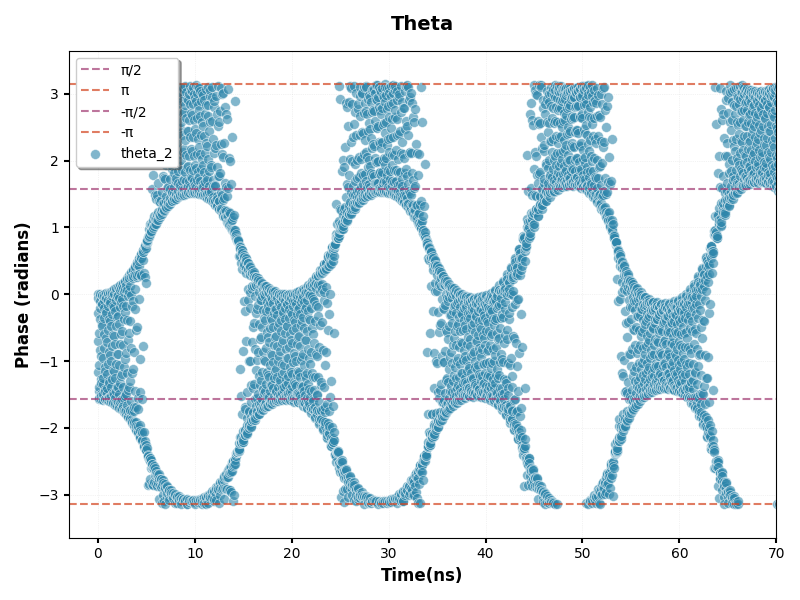

In [9]:


fig, ax2 = plt.subplots(1, 1, figsize=(8, 6))
ax2.axhline(y=np.pi/2, color='#A23B72', linestyle='--', linewidth=1.5, alpha=0.7, label='π/2')
ax2.axhline(y=np.pi, color="#D34420", linestyle='--', linewidth=1.5, alpha=0.7, label='π')
ax2.axhline(y= -np.pi/2, color='#A23B72', linestyle='--', linewidth=1.5, alpha=0.7, label='-π/2')
ax2.axhline(y= -np.pi, color="#D34420", linestyle='--', linewidth=1.5, alpha=0.7, label='-π')
ax2.scatter(tlist1, theta3, color='#2E86AB', s=50, alpha=0.6, edgecolors='white', linewidth=0.5, label='theta_2')
ax2.legend(loc='best', frameon=True, fancybox=True, shadow=True, fontsize=10)
ax2.set_xlabel('Time(ns)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Phase (radians)', fontsize=12, fontweight='bold')
ax2.set_title('Theta', fontsize=14, fontweight='bold', pad=15)
ax2.grid(True, alpha=0.3, linestyle=':', linewidth=0.5)
ax2.set_axisbelow(True) 
y_min =  min(theta3) -0.5
y_max = max(theta3) +0.5
ax2.set_ylim(y_min, y_max)
ax2.set_xlim(-3,70)
ax2.tick_params(axis='both', which='major', labelsize=10, width=1.5)
ax2.tick_params(axis='both', which='minor', labelsize=8)
ax2.spines['top'].set_visible(True)
ax2.spines['right'].set_visible(True)
plt.tight_layout()
plt.show()


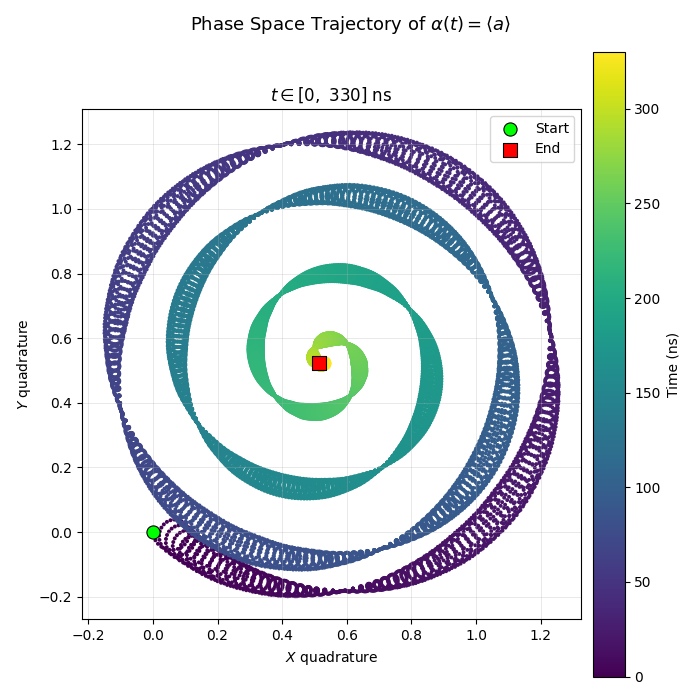

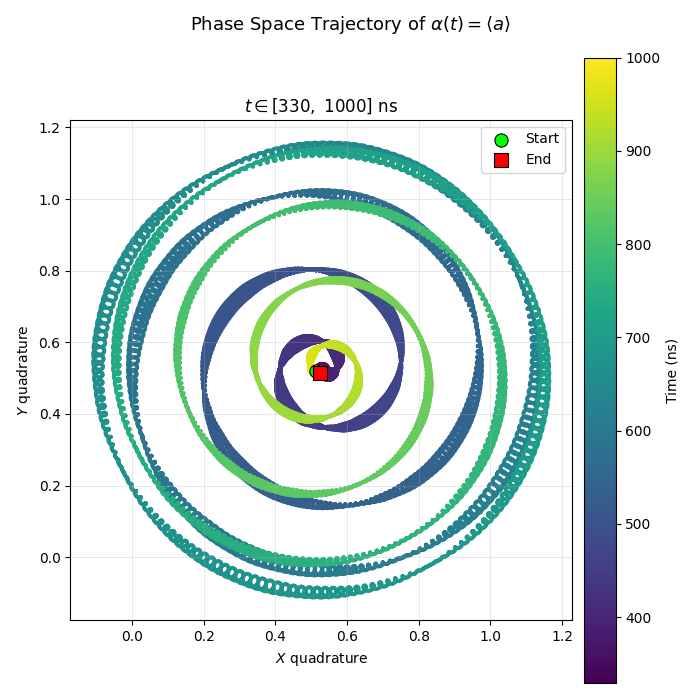

In [10]:
alpha_t = output1.expect[3]          
x_quad = np.real(alpha_t)            
y_quad = np.imag(alpha_t)          
t   = tlist1                          
idx = np.searchsorted(t, 330)         
x1, y1, t1 = x_quad[:idx],  y_quad[:idx],  t[:idx]   
x2, y2, t2 = x_quad[idx:],  y_quad[idx:],  t[idx:]   

def plot_phase_space(x, y, t, title):
    """Standalone figure for each time interval."""
    fig, ax = plt.subplots(figsize=(7, 7))

    norm = mcolors.Normalize(vmin=t[0], vmax=t[-1])
    sc   = ax.scatter(x, y, c=t, cmap='viridis',
                      norm=norm, s=8, linewidths=0)

    # connecting line
    ax.plot(x, y, color='gray', lw=0.4, alpha=0.35, zorder=0)

    # start and end markers
    ax.scatter(x[0],  y[0],  marker='o', s=90,
               color='lime', edgecolors='black', lw=0.8,
               zorder=5, label='Start')
    ax.scatter(x[-1], y[-1], marker='s', s=90,
               color='red',  edgecolors='black', lw=0.8,
               zorder=5, label='End')

    ax.set_xlabel(r'$X$ quadrature')
    ax.set_ylabel(r'$Y$ quadrature')
    ax.set_title(title, fontsize=12)
    ax.set_aspect('equal')
    ax.grid(True, lw=0.5, alpha=0.4)
    ax.legend(loc='upper right')

    cbar = fig.colorbar(sc, ax=ax, pad=0.02)
    cbar.set_label('Time (ns)')

    fig.suptitle(r'Phase Space Trajectory of $\alpha(t) = \langle a \rangle$'
                 '', fontsize=13)
    fig.tight_layout()

    

    plt.show()

# --- Plot 1: 0–330 ns ---
plot_phase_space(x1, y1, t1,
    r'$t \in [0,\ 330]$ ns')

# --- Plot 2: 330–1000 ns ---
plot_phase_space(x2, y2, t2,
    r'$t \in [330,\ 1000]$ ns')

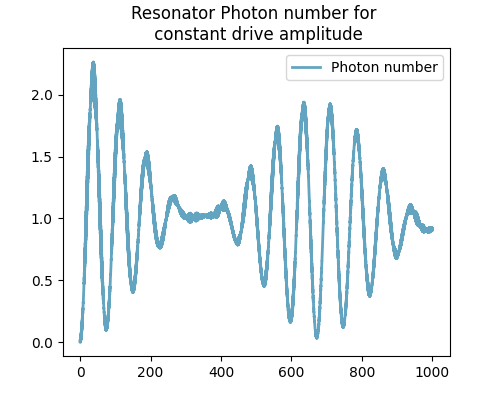

In [11]:
fig , ax =plt.subplots(1,1,figsize=(5,4))
ax.plot(tlist1, output1.expect[0], label='Photon number', linewidth=2, color="#3C8EB1", alpha=0.8)
ax.set_title("Resonator Photon number for \n constant drive amplitude")
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)
ax.legend()
plt.show()

In [ ]:
output2 = mesolve(H_cck,psi0,tlist1,c_ops= c_ops,e_ops=[num,r_x,r_Y,a],options= {'store_states': True,'progress_bar':True})

In [ ]:

imag_part= np.imag(output1.expect[2])
fig, ax1 = plt.subplots(1,1,figsize=(8,6))
ax1.plot(tlist1,np.real(output1.expect[3]),label='Re[<a>]')
ax1.plot(tlist1,np.imag(output1.expect[3]),label='Img[<a>]')
ax1.plot(tlist1,np.real(output2.expect[3]),label='Re[<r_X>]')
ax1.plot(tlist1,np.imag(output2.expect[3]),label='Img[<r_Y>]')
ax1.legend()
plt.show()

In [ ]:
def phase_f(fullev_qutrit,n):
    
    
    mu_00_00 =[]
    mu_00_01 =[]
    mu_00_10 =[]
    mu_00_11 =[]
    
    mu_00_00_r =[]
    mu_00_01_r =[]
    mu_00_10_r =[]
    mu_00_11_r =[]

    mu_00_00_i =[]
    mu_00_01_i =[]
    mu_00_10_i =[]
    mu_00_11_i =[]

    for i in range(len(fullev_qutrit)):
        
        rho = fullev_qutrit[i]
        index = [0,1,3,4]
        mu_00_00.append(rho[0,0])
        mu_00_01.append(rho[0,1])
        mu_00_10.append(rho[0,3])
        mu_00_11.append(rho[0,4])

        mu_00_00_r.append(rho[0,0].real)
        mu_00_01_r.append(rho[0,1].real)
        mu_00_10_r.append(rho[0,3].real)
        mu_00_11_r.append(rho[0,4].real)

        mu_00_00_i.append(rho[0,0].imag)
        mu_00_01_i.append(rho[0,1].imag)
        mu_00_10_i.append(rho[0,3].imag)
        mu_00_11_i.append(rho[0,4].imag)

    th_00_00 = []
    th_00_01 = []
    th_00_10 = []
    th_00_11 = []

    for i in range(len(fullev_qutrit)):
        th_00_00.append(np.arctan2(mu_00_00_i[i],mu_00_00_r[i])+np.pi)
        th_00_01.append(np.arctan2(mu_00_01_i[i],mu_00_01_r[i])+np.pi)
        th_00_10.append(np.arctan2(mu_00_10_i[i],mu_00_10_r[i])+np.pi)
        th_00_11.append(np.arctan2(mu_00_11_i[i],mu_00_11_r[i])+np.pi)
    if n==1:
        return th_00_00,th_00_01,th_00_10,th_00_11
    elif n==2:
        return mu_00_00,mu_00_01,mu_00_10,mu_00_11
    elif n==3:
        return mu_00_00_r,mu_00_01_r,mu_00_10_r,mu_00_11_r,mu_00_00_i,mu_00_01_i,mu_00_10_i,mu_00_11_i
    else:
        return "n=1,2,3"
    
def qubit_matrix(fullev_state):
    qubit_subspace = []
    for i in range(len(fullev_state)):
        qubit_subspace.append((fullev_state[i].ptrace([0,1])).full())
    return qubit_subspace

In [ ]:
fullev_state = output1.states
fullev_qutrit = qubit_matrix(fullev_state)
c0000r,c0001r,c0010r,c0011r,c0000i,c0001i,c0010i,c0011i =phase_f(fullev_qutrit,3)

angle0000 = np.angle(np.asarray(c0000r)+ 1j*np.asarray(c0000i))
angle0001 = np.angle(np.asarray(c0001r)+ 1j*np.asarray(c0001i))
angle0010 = np.angle(np.asarray(c0010r)+ 1j*np.asarray(c0010i))
angle0011 = np.angle(np.asarray(c0011r)+ 1j*np.asarray(c0011i))

unwrap_0000 =np.unwrap(angle0000)
unwrap_0001 =np.unwrap(angle0001)
unwrap_0010 =np.unwrap(angle0010)
unwrap_0011 =np.unwrap(angle0011)


df = pd.DataFrame({
    "t": np.asarray(tlist1),
    "c0000r": np.asarray(c0000r,dtype=np.float64),
    "c0000i": np.asarray(c0000i,dtype=np.float64),

    "c0001r": np.asarray(c0001r,dtype=np.float64),
    "c0001i":np.asarray(c0001i,dtype=np.float64),

    "c0010r":np.asarray(c0010r,dtype=np.float64),
    "c0010i":np.asarray(c0010i,dtype=np.float64),

    "c0011r":np.asarray(c0011r,dtype=np.float64),
    "c0011i":np.asarray(c0011i,dtype=np.float64),

    "<n>":np.asarray(output1.expect[0],dtype=np.float64),
    "Re[<a>]":np.asarray(np.real(output1.expect[3]),dtype=np.float64),
    "Imag[<a>]":np.asarray(np.imag(output1.expect[3]),dtype=np.float64),

    "phi0000" :angle0000,
    "phi0001" :angle0001,
    "phi0010" :angle0010,
    "phi0011" :angle0011,

    "unwrap0000":unwrap_0000,
    "unwrap0001":unwrap_0001,
    "unwrap0010":unwrap_0010,
    "unwrap0011":unwrap_0011,


})


In [ ]:
c00,c01,c10,c11 = phase_f(fullev_qutrit,2)
c00_2,c01_2,c10_2,c11_2 = phase_f(fullev_qutrit2,2)


df = pd.DataFrame({
    "t": np.asarray(tlist1),
    "mu_00_01": np.asarray(c01),
    "mu_00_10": np.asarray(c10),
    "mu_00_11": np.asarray(c11),

})
folder_path = r"D:\MS Thesis\4_Qubit\Data"
file_name = "Full evolution coeff.csv"
os.makedirs(folder_path, exist_ok=True)
full_path = os.path.join(folder_path, file_name)
df.to_csv(full_path, index=False)



theta =[]
for i in range(len(tlist1)):
    theta.append(np.angle((c01[i]*c10[i]*c01_2[i]*c11_2[i])/(c11[i]*c11_2[i])))

fig ,ax2 = plt.subplots(1,1,figsize =(8,6))
ax2.plot(tlist1,theta)
plt.show()



In [ ]:

fig2, ax2 = plt.subplots(1,3,figsize=(8,6))
ax2[0].plot(tlist1,mu_00_01_r,label='Real')
ax2[0].plot(tlist1,mu_00_01_i,label='Imag')
ax2[0].plot(tlist1,output1.expect[0],label ='<n>')
ax2[0].scatter(tlist1,th_00_01,label='phase')
ax2[0].legend()

ax2[1].plot(tlist1,phase_unwrapped,label='phase')
ax2[2].plot(tlist1,diff,label='diff')

plt.show()